<a href="https://colab.research.google.com/github/riyayd/RelevantProjects/blob/main/HRAnalytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_excel('/content/Copy of People Charm_data.xlsx', sheet_name = 'Data') #uploads the specific subsheet from an excel file
df.head(5)

,satisfactoryLevel,lastEvaluation,numberOfProjects,avgMonthlyHours,timeSpent.company,workAccident,left,promotionInLast5years,dept,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.37,0.52,2,159,3,0,1,0,sales,low
4,0.41,0.50,2,153,3,0,1,0,sales,low


Basic EDA:

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfactoryLevel      14999 non-null  float64
 1   lastEvaluation         14999 non-null  float64
 2   numberOfProjects       14999 non-null  int64  
 3   avgMonthlyHours        14999 non-null  int64  
 4   timeSpent.company      14999 non-null  int64  
 5   workAccident           14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotionInLast5years  14999 non-null  int64  
 8   dept                   14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [ ]:
df.isnull().sum()

,0
satisfactoryLevel,0
lastEvaluation,0
numberOfProjects,0
avgMonthlyHours,0
timeSpent.company,0
workAccident,0
left,0
promotionInLast5years,0
dept,0
salary,0


In [ ]:
df.duplicated().sum()

3008

In [ ]:
df = df.drop_duplicates(keep='first')
#keep='first' deletes all duplicates but the first
#keep='last deletes all duplicates but the last
#keep=False deletes all duplicates

In [ ]:
df.rename(columns={'timeSpent.company':'timeSpent_company'}, inplace = True)

Normality test:


Check whether the data is normally distributed or not in 'satisfactory level' column using Shapiro-Wilk test

(array([ 880.,  429.,  386., 1095., 1242., 1540., 1535., 1718., 1621.,
        1545.]),
 array([0.09 , 0.181, 0.272, 0.363, 0.454, 0.545, 0.636, 0.727, 0.818,
        0.909, 1.   ]),
 <BarContainer object of 10 artists>)

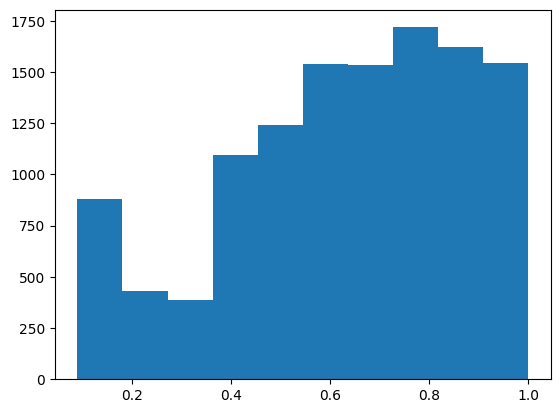

In [ ]:
plt.hist(df['satisfactoryLevel'])

<Axes: xlabel='satisfactoryLevel', ylabel='Density'>

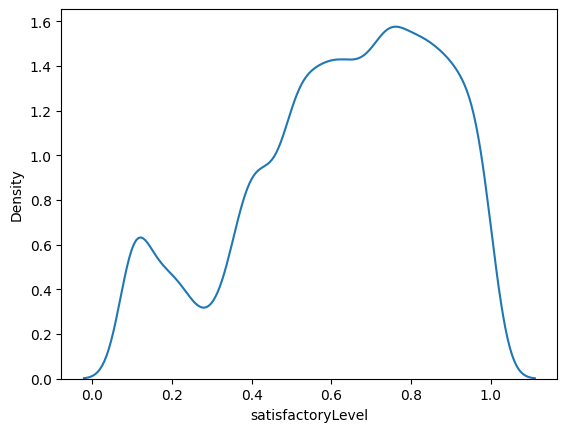

In [ ]:
sns.kdeplot(df['satisfactoryLevel'])

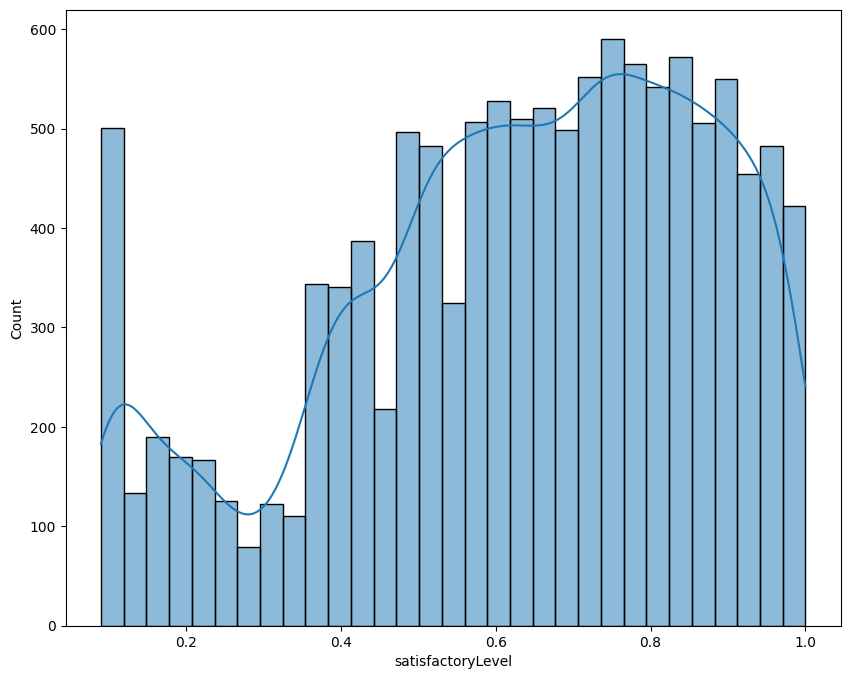

In [ ]:
plt.figure(figsize=(10,8))
sns.histplot(df['satisfactoryLevel'], kde = True)
plt.show()

In [ ]:
df['satisfactoryLevel'].describe()

,satisfactoryLevel
count,11991.000000
mean,0.629658
std,0.241070
min,0.090000
25%,0.480000
50%,0.660000
75%,0.820000
max,1.000000


In [ ]:
df['satisfactoryLevel'].mode()

,satisfactoryLevel
0,0.74


Shapiro-Wilk Test:

This is a hypothesis test used to check if the data is normally ditributed.

Null Hypothesis - the data is normally distributed

Alt Hypothesis - the data is NOT normally distributed

In [ ]:
from scipy.stats import shapiro

In [ ]:
stat, p_value = shapiro(df['satisfactoryLevel'])
if p_value < 0.05:
  print('Null Hypothesis Rejected - the data is normally NOT distributed')
else:
  print('Null Hypothesis Accepted - the data is normally distributed')

Null Hypothesis Rejected - the data is normally NOT distributed


In [ ]:
df['salary'].unique()

array(['low', 'medium', 'high'], dtype=object)

In [ ]:
df1 = df.copy()
df1.head()

,satisfactoryLevel,lastEvaluation,numberOfProjects,avgMonthlyHours,timeSpent_company,workAccident,left,promotionInLast5years,dept,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.37,0.52,2,159,3,0,1,0,sales,low
4,0.41,0.50,2,153,3,0,1,0,sales,low


In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
le = LabelEncoder()
df1['salary'] = le.fit_transform(df1['salary'])

In [ ]:
df1['salary'].unique()

array([1, 2, 0])

<Axes: >

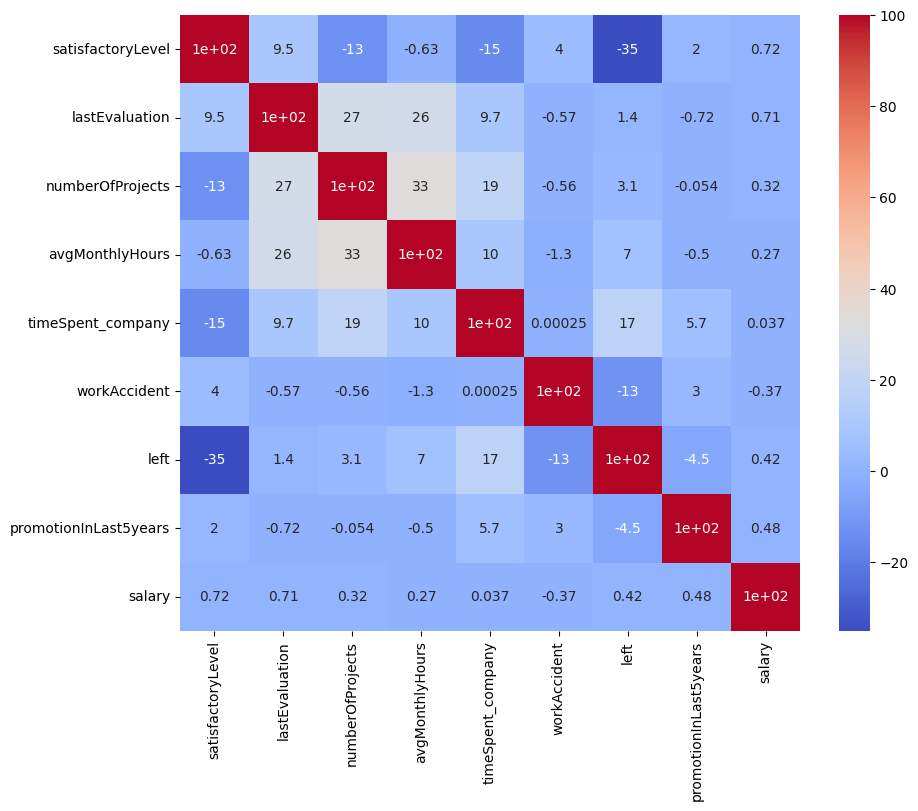

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df1.corr(numeric_only=True)*100, cmap='coolwarm', annot=True)

One Sample T-Test:

The average monthy hours of an employee having 2 years experience is 167. Is it the same for employees having more than 2 years experience?

Condition - Satisfactory level of an employee is from 0-0.05 and AvgMonthlyHours is from 130-200.

Null - The average monthy hours of an employee having 2 years experience is 167.

Alt - The average monthy hours of an employee having 2 years experience is NOT 167.

In [ ]:
df

,satisfactoryLevel,lastEvaluation,numberOfProjects,avgMonthlyHours,timeSpent_company,workAccident,left,promotionInLast5years,dept,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.37,0.52,2,159,3,0,1,0,sales,low
4,0.41,0.50,2,153,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14992,0.30,0.88,5,245,4,0,0,0,hr,low
14995,0.99,0.83,4,274,2,0,0,0,sales,low
14996,0.72,0.72,4,175,4,0,0,0,technical,low
14997,0.24,0.91,5,177,5,0,0,0,sales,low


In [ ]:
df2=df[(df.satisfactoryLevel>=0) & (df.satisfactoryLevel<=0.5 ) & (df.avgMonthlyHours>=130) & (df.avgMonthlyHours<=200) & (df.timeSpent_company>=3)]

In [ ]:
df2.head(5)

,satisfactoryLevel,lastEvaluation,numberOfProjects,avgMonthlyHours,timeSpent_company,workAccident,left,promotionInLast5years,dept,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
3,0.37,0.52,2,159,3,0,1,0,sales,low
4,0.41,0.50,2,153,3,0,1,0,sales,low
7,0.42,0.53,2,142,3,0,1,0,sales,low
8,0.45,0.54,2,135,3,0,1,0,sales,low


In [ ]:
samplesize = int(0.1*1462)
sample1 = df2.sample(samplesize, random_state = 0)

In [ ]:
sample1

,satisfactoryLevel,lastEvaluation,numberOfProjects,avgMonthlyHours,timeSpent_company,workAccident,left,promotionInLast5years,dept,salary
1685,0.17,0.76,4,171,5,0,0,0,product_mng,low
11633,0.46,0.46,2,145,3,0,1,0,IT,high
1250,0.45,0.53,2,159,3,0,1,0,sales,low
774,0.45,0.49,2,144,3,0,1,0,accounting,low
3506,0.50,0.38,5,175,4,0,0,0,technical,high
...,...,...,...,...,...,...,...,...,...,...
14803,0.42,0.52,2,151,3,0,1,0,sales,medium
291,0.41,0.52,2,136,3,0,1,0,technical,low
12915,0.48,0.51,4,152,4,0,0,0,accounting,high
7064,0.41,0.68,3,191,4,0,0,0,sales,medium


In [ ]:
from scipy.stats import ttest_1samp


In [ ]:
t_stat,P_val = ttest_1samp(sample1['avgMonthlyHours'], 167)
print("p value is ", P_val)
if P_val < 0.05:
  print("ALT - The average monthy hours of an employee having 2 years experience is NOT 167.")
else:
  print("Null - The average monthy hours of an employee having 2 years experience is 167.")

p value is  1.513556976804864e-15
ALT - The average monthy hours of an employee having 2 years experience is NOT 167.


Proportions Z Test:

The percentage of employees leaving the company is 3% having experience of 2 years. Is it the same for meployees having more than 2 years of experience?

In [ ]:
df2

,satisfactoryLevel,lastEvaluation,numberOfProjects,avgMonthlyHours,timeSpent_company,workAccident,left,promotionInLast5years,dept,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
3,0.37,0.52,2,159,3,0,1,0,sales,low
4,0.41,0.50,2,153,3,0,1,0,sales,low
7,0.42,0.53,2,142,3,0,1,0,sales,low
8,0.45,0.54,2,135,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14877,0.45,0.47,2,146,3,0,1,0,sales,medium
14900,0.45,0.46,2,142,3,0,1,0,product_mng,low
14915,0.39,0.57,2,131,3,0,1,0,support,medium
14937,0.25,0.69,3,187,4,0,0,0,marketing,medium


In [ ]:
from statsmodels.stats.proportion import proportions_ztest

Null - The percentage of employees leaving the company is 3% having experience of 2 years.

Alt - The percentage of employees leaving the company is NOT 3% having experience of 2 years.

In [ ]:
count = sample1['left'].value_counts()[1]
count

94

In [ ]:
nobs = len(sample1['left'])
nobs

146

In [ ]:
p0 = 0.03
stats, P_value = proportions_ztest(count, nobs, p0)
P_value

4.133849519556016e-54

In [ ]:
if P_value < 0.05:
  print("ALT - The average monthy hours of an employee having 2 years experience is NOT 3%.")
else:
  print("Null - The average monthy hours of an employee having 2 years experience is 3%.")

ALT - The average monthy hours of an employee having 2 years experience is NOT 3%.
